# Cross-Recording Corroboration & State Capture Analysis

**Author:** Niko Gamulin, PhD | **Date:** March 2026 | **License:** MIT

## Beyond Signal Analysis

Signal-level authentication and ENF dating address **technical authenticity**. The strongest evidence comes from **content corroboration**: do independent speakers, recorded separately, describe the same mechanisms?

Topics mentioned by 3+ independent speakers are extremely difficult to fabricate across uncoordinated individuals.

### Methodology

1. All 14 recordings transcribed (OpenAI Whisper API, manual verification of key quotes)
2. 10 topic groups identified through systematic content coding
3. Corroboration counted per topic: number of independent speakers
4. Relational mapping: who mentions whom across recordings


In [1]:
import sys
sys.path.insert(0, '.')
from style import apply_style, COLORS, PALETTE
apply_style()

import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, FancyArrowPatch
from IPython.display import Image, display
import io, os

FIGURE_DIR = '../figures/corroboration/'
os.makedirs(FIGURE_DIR, exist_ok=True)

with open('../data/metadata.json') as f:
    meta = json.load(f)

speakers = meta['speakers']
print(f"Recordings: {len(meta['recordings'])} | Speakers: {len(speakers)}")
for name, info in speakers.items():
    print(f"  {name} ({info['role']}): {len(info['recordings'])} recordings")


Recordings: 14 | Speakers: 7
  Dominika Svarc Pipan (Former Minister of Justice): 3 recordings
  Nina Zidar Klemencic (Senior Judicial Official): 2 recordings
  Vesna Vukovic (Journalist / Media Figure): 2 recordings
  Rok Hodej (Political Operative): 2 recordings
  Dejan Paravan (Business Figure): 1 recordings
  Tomislav Vukmanovic (Business Figure): 1 recordings
  Joze Oberstar (Former DARS Executive): 3 recordings


  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Eight State Capture Mechanisms

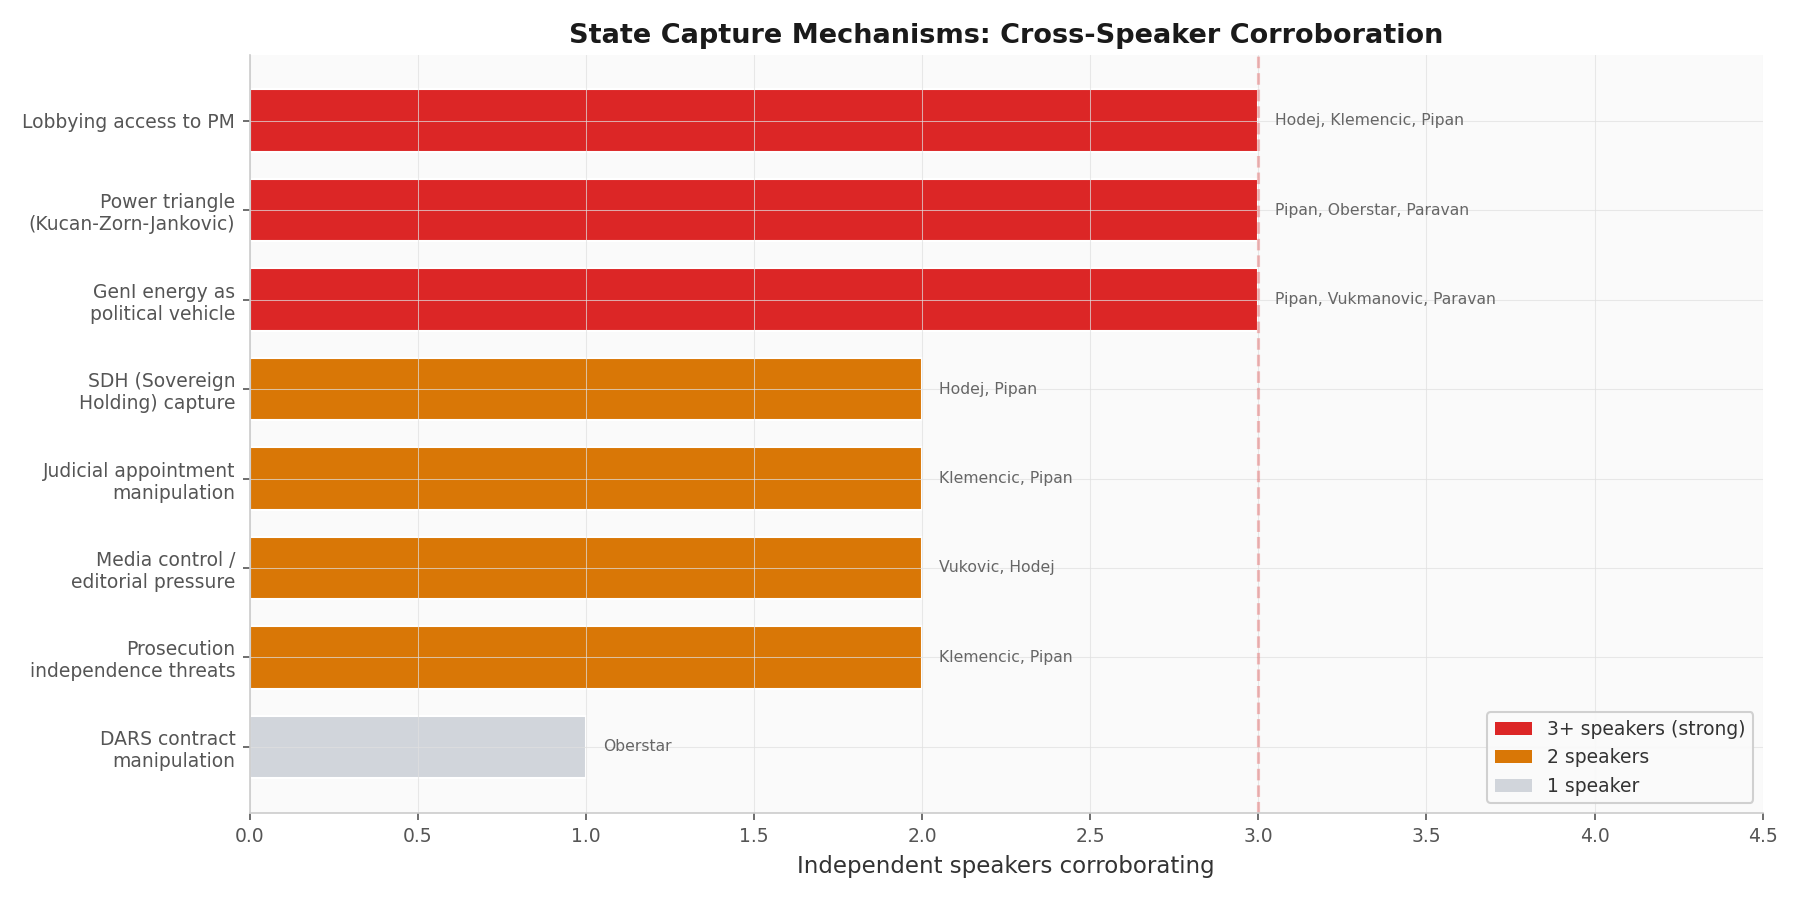

In [2]:
mechanisms = [
    {"name": "Lobbying access to PM", "speakers": ["Rok Hodej", "Nina Zidar Klemencic", "Dominika Svarc Pipan"], "corr": 3},
    {"name": "Power triangle\n(Kucan-Zorn-Jankovic)", "speakers": ["Dominika Svarc Pipan", "Joze Oberstar", "Dejan Paravan"], "corr": 3},
    {"name": "GenI energy as\npolitical vehicle", "speakers": ["Dominika Svarc Pipan", "Tomislav Vukmanovic", "Dejan Paravan"], "corr": 3},
    {"name": "SDH (Sovereign\nHolding) capture", "speakers": ["Rok Hodej", "Dominika Svarc Pipan"], "corr": 2},
    {"name": "Judicial appointment\nmanipulation", "speakers": ["Nina Zidar Klemencic", "Dominika Svarc Pipan"], "corr": 2},
    {"name": "DARS contract\nmanipulation", "speakers": ["Joze Oberstar"], "corr": 1},
    {"name": "Media control /\neditorial pressure", "speakers": ["Vesna Vukovic", "Rok Hodej"], "corr": 2},
    {"name": "Prosecution\nindependence threats", "speakers": ["Nina Zidar Klemencic", "Dominika Svarc Pipan"], "corr": 2},
]
mechanisms.sort(key=lambda x: x['corr'], reverse=True)

fig, ax = plt.subplots(figsize=(12, 6))

names = [m['name'] for m in mechanisms]
corrs = [m['corr'] for m in mechanisms]
colors = [COLORS['secondary'] if c >= 3 else COLORS['warning'] if c >= 2 else COLORS['light_gray'] for c in corrs]

bars = ax.barh(range(len(names)), corrs, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('Independent speakers corroborating', fontsize=11)
ax.set_title('State Capture Mechanisms: Cross-Speaker Corroboration', fontsize=13)
ax.axvline(3, color=COLORS['secondary'], linestyle='--', alpha=0.3)

# Add speaker names on bars
for i, m in enumerate(mechanisms):
    speaker_str = ', '.join([s.split()[-1] for s in m['speakers']])
    ax.text(m['corr'] + 0.05, i, speaker_str, va='center', fontsize=7.5, color='#666666')

ax.set_xlim(0, max(corrs) + 1.5)
ax.invert_yaxis()

legend_els = [Patch(facecolor=COLORS['secondary'], label='3+ speakers (strong)'),
              Patch(facecolor=COLORS['warning'], label='2 speakers'),
              Patch(facecolor=COLORS['light_gray'], label='1 speaker')]
ax.legend(handles=legend_els, loc='lower right', fontsize=9)

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'corroboration_chart.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))


## Topic-Speaker Matrix

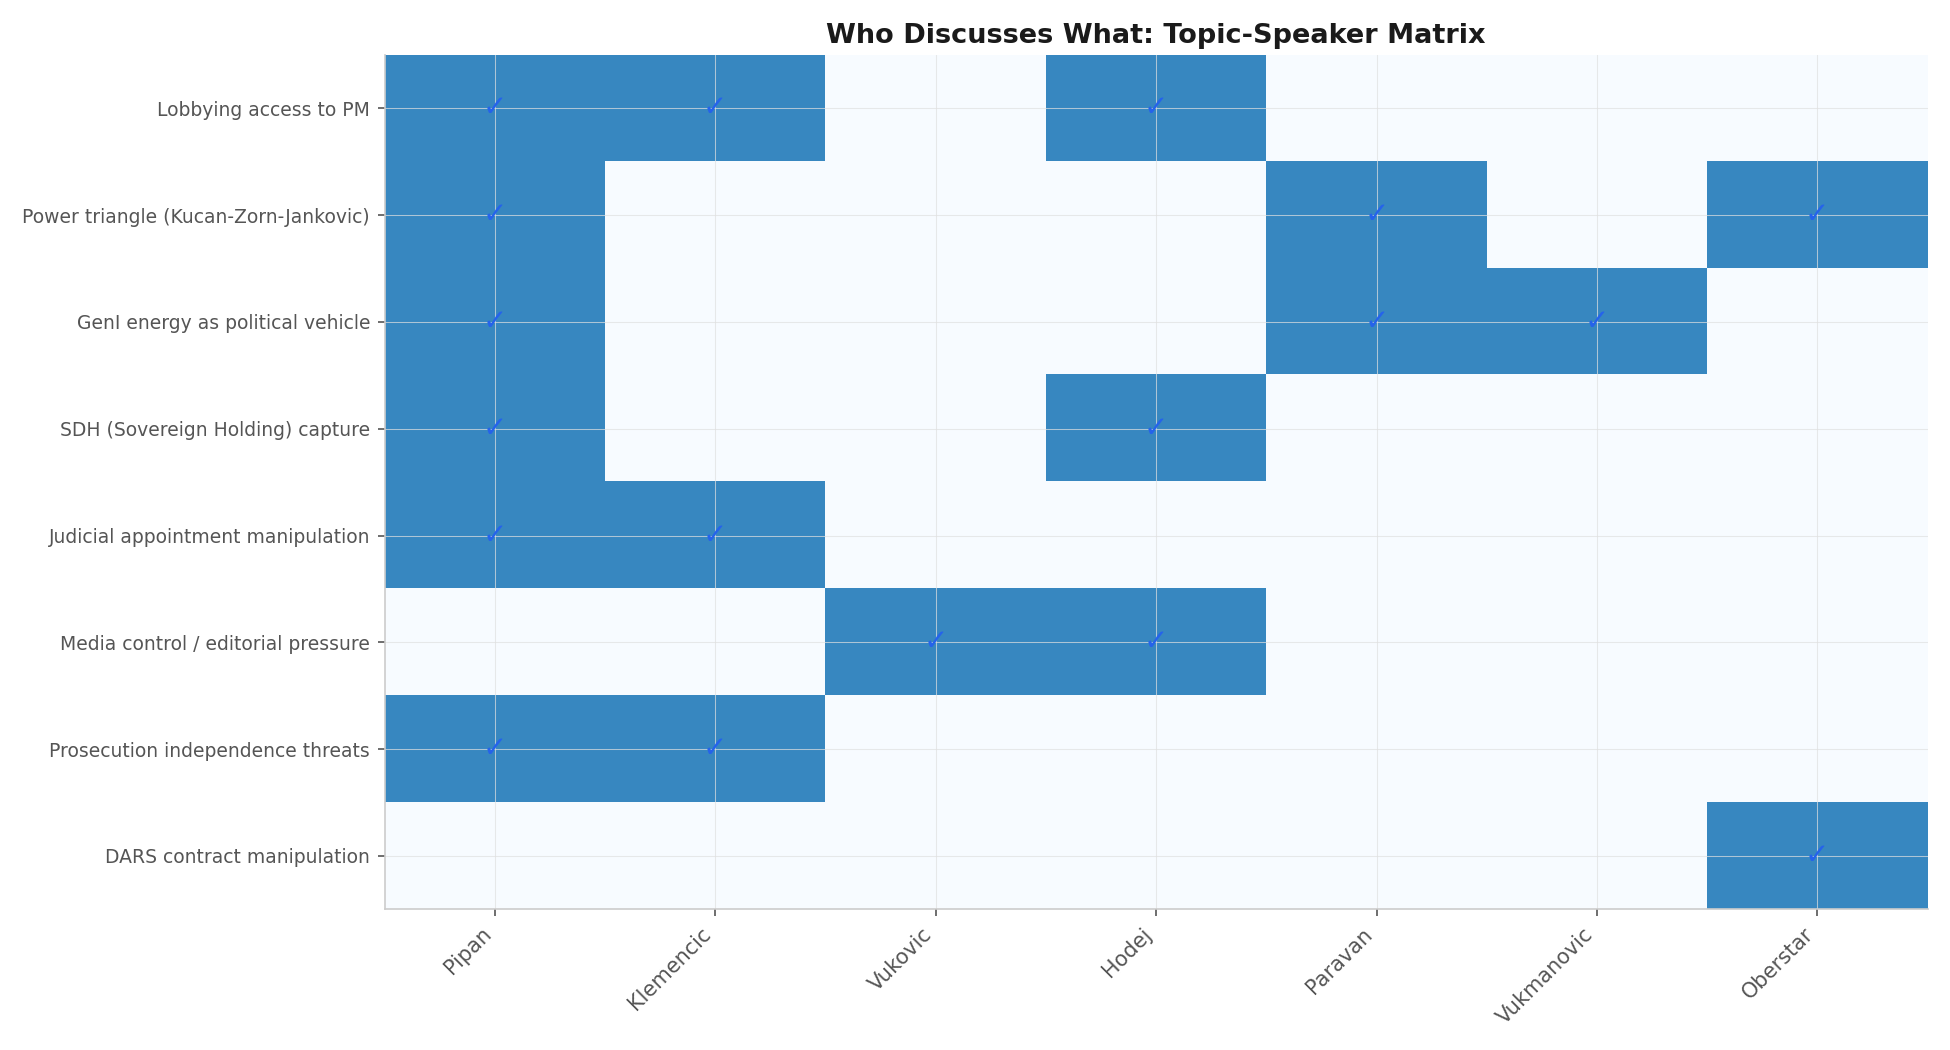

In [3]:
# Heatmap
all_speakers = list(speakers.keys())
topic_names_clean = [m['name'].replace('\n', ' ') for m in mechanisms]

matrix = np.zeros((len(mechanisms), len(all_speakers)))
for i, m in enumerate(mechanisms):
    for j, s in enumerate(all_speakers):
        if s in m['speakers']:
            matrix[i, j] = 1

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(matrix, cmap='Blues', aspect='auto', vmin=0, vmax=1.5)

ax.set_xticks(range(len(all_speakers)))
ax.set_xticklabels([s.split()[-1] for s in all_speakers], rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(topic_names_clean)))
ax.set_yticklabels(topic_names_clean, fontsize=9)
ax.set_title('Who Discusses What: Topic-Speaker Matrix', fontsize=13)

for i in range(len(topic_names_clean)):
    for j in range(len(all_speakers)):
        if matrix[i, j] > 0:
            ax.text(j, i, '\u2713', ha='center', va='center', fontsize=14, fontweight='bold', color=COLORS['primary'])

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'topic_speaker_matrix.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))


## Relational Graph: Who Mentions Whom

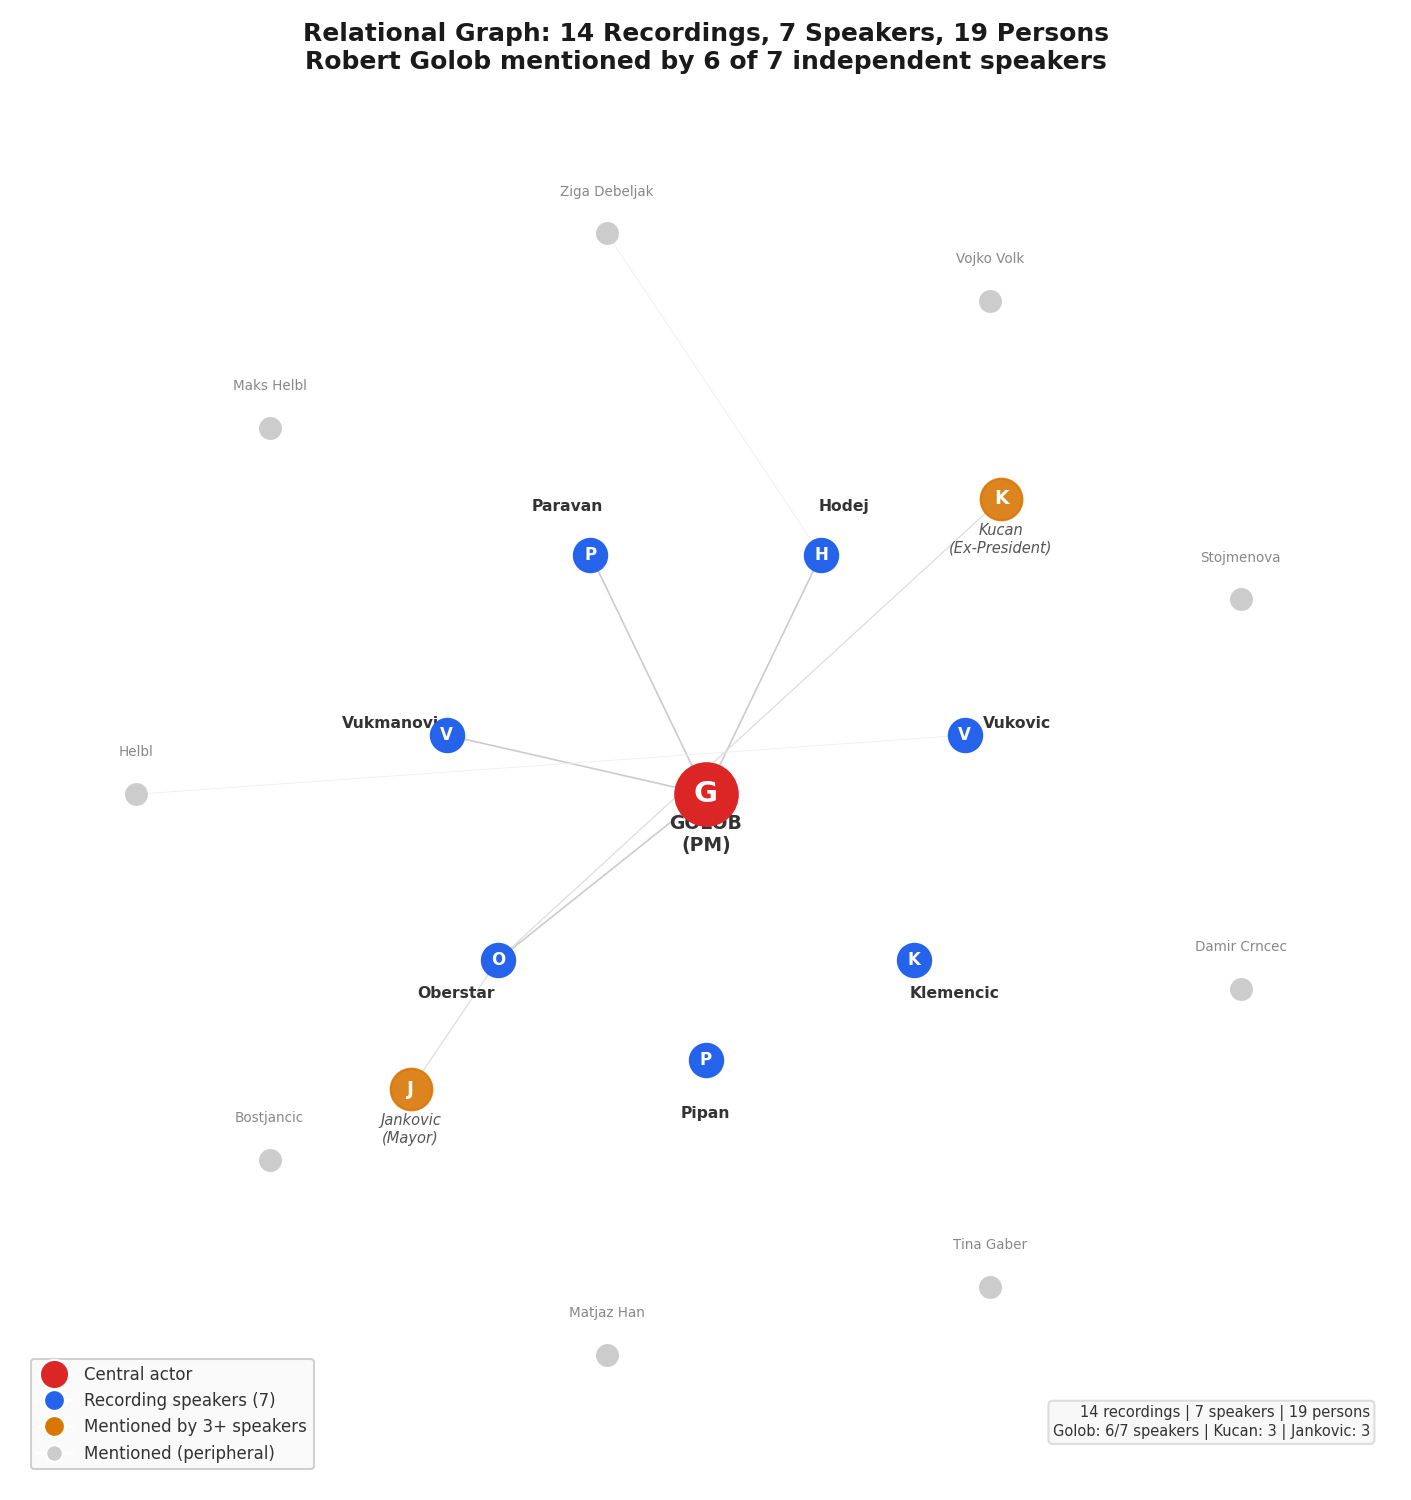

In [4]:
key_figures = {
    "Robert Golob": {"by": ["Svarc Pipan", "Hodej", "Zidar Klemencic", "Oberstar", "Vukmanovic", "Paravan"], "role": "PM", "group": "central"},
    "Milan Kucan": {"by": ["Svarc Pipan", "Oberstar", "Zidar Klemencic"], "role": "Ex-President", "group": "major"},
    "Zoran Jankovic": {"by": ["Svarc Pipan", "Oberstar", "Zidar Klemencic"], "role": "Mayor", "group": "major"},
}

peripheral = {
    "Tina Gaber": {"by": ["Svarc Pipan"], "role": "First Lady"},
    "Damir Crncec": {"by": ["Svarc Pipan"], "role": "Fmr State Sec Defense"},
    "Stojmenova": {"by": ["Svarc Pipan"], "role": "Fmr Min Digital"},
    "Vojko Volk": {"by": ["Svarc Pipan"], "role": "State Sec Security"},
    "Ziga Debeljak": {"by": ["Svarc Pipan", "Hodej"], "role": "SDH Board"},
    "Maks Helbl": {"by": ["Svarc Pipan"], "role": "GEN-I Board"},
    "Helbl": {"by": ["Svarc Pipan", "Vukovic"], "role": "Sec Gen Government"},
    "Bostjancic": {"by": ["Zidar Klemencic"], "role": "Finance Min"},
    "Matjaz Han": {"by": ["Zidar Klemencic"], "role": "Economy Min"},
}

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

n_speakers = len(speakers)
n_periph = len(peripheral)
n_total = 1 + n_speakers + 2 + n_periph  # golob + speakers + kucan/jankovic + peripheral

ax.set_title(f'Relational Graph: 14 Recordings, 7 Speakers, {n_total} Persons\n'
             f'Robert Golob mentioned by 6 of 7 independent speakers', 
             fontsize=12, fontweight='bold', pad=20)

# Center: Golob
ax.plot(0, 0, 'o', markersize=30, color=COLORS['secondary'], zorder=5)
ax.text(0, 0, 'G', ha='center', va='center', fontsize=14, color='white', fontweight='bold', zorder=6)
ax.annotate('GOLOB\n(PM)', (0, -0.15), ha='center', fontsize=9, fontweight='bold', color='#333333')

# Speakers in inner ring
speaker_names = list(speakers.keys())
speaker_pos = {}
for i, name in enumerate(speaker_names):
    angle = 2 * np.pi * i / len(speaker_names) - np.pi/2
    x, y = 0.7 * np.cos(angle), 0.7 * np.sin(angle)
    short = name.split()[-1]
    speaker_pos[short] = (x, y)
    ax.plot(x, y, 'o', markersize=16, color=COLORS['primary'], zorder=5)
    ax.text(x, y, short[0], ha='center', va='center', fontsize=8, color='white', fontweight='bold', zorder=6)
    label_angle = np.arctan2(y, x)
    lx = x + 0.14 * np.cos(label_angle)
    ly = y + 0.14 * np.sin(label_angle)
    ax.annotate(short, (lx, ly), ha='center', va='center', fontsize=7.5, fontweight='bold', color='#333333')
    # Line to Golob for speakers who mention him
    golob_info = key_figures["Robert Golob"]
    if short in golob_info["by"]:
        ax.plot([0, x], [0, y], '-', color='#cccccc', lw=0.8, zorder=1)

# Major mentioned (Kucan, Jankovic) in mid ring
major_positions = {}
major_list = [(k,v) for k,v in key_figures.items() if v.get("group") == "major"]
for i, (name, info) in enumerate(major_list):
    angle = np.pi/4 + i * np.pi  # opposite sides
    x, y = 1.1 * np.cos(angle), 1.1 * np.sin(angle)
    major_positions[name] = (x, y)
    ax.plot(x, y, 'o', markersize=20, color=COLORS['warning'], alpha=0.9, zorder=5)
    short = name.split()[-1]
    ax.text(x, y, short[0], ha='center', va='center', fontsize=9, color='white', fontweight='bold', zorder=6)
    ax.annotate(f'{short}\n({info["role"]})', (x, y - 0.14), ha='center', fontsize=7, style='italic', color='#555555')
    # Lines from speakers who mention them
    for surname in info['by']:
        if surname in speaker_pos:
            sx, sy = speaker_pos[surname]
            ax.plot([x, sx], [y, sy], '-', color='#dddddd', lw=0.6, zorder=1)

# Peripheral nodes in outer ring
periph_names = list(peripheral.keys())
for i, name in enumerate(periph_names):
    angle = 2 * np.pi * i / len(periph_names) - np.pi/3
    x, y = 1.5 * np.cos(angle), 1.5 * np.sin(angle)
    ax.plot(x, y, 'o', markersize=10, color='#cccccc', zorder=5)
    info = peripheral[name]
    ax.annotate(name, (x, y + 0.1), ha='center', fontsize=6.5, color='#888888')
    # Lines from speakers
    for surname in info['by']:
        if surname in speaker_pos:
            sx, sy = speaker_pos[surname]
            ax.plot([x, sx], [y, sy], '-', color='#eeeeee', lw=0.4, zorder=1)

# Legend
legend_els = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS['secondary'], markersize=14, label='Central actor'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS['primary'], markersize=10, label='Recording speakers (7)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLORS['warning'], markersize=10, label='Mentioned by 3+ speakers'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#cccccc', markersize=8, label='Mentioned (peripheral)'),
]
ax.legend(handles=legend_els, loc='lower left', fontsize=8, framealpha=0.9)

# Stats box
stats_text = f"14 recordings | 7 speakers | {n_total} persons\nGolob: 6/7 speakers | Kucan: 3 | Jankovic: 3"
ax.text(1.75, -1.7, stats_text, fontsize=7, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f8f8f8', edgecolor='#dddddd'))

plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'relational_graph_en.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))


## Why Corroboration Matters More Than Signal Analysis

To fabricate this level of cross-speaker consistency, one would need to:
1. Record 7 different people separately
2. Coordinate their narratives to mention the same names, mechanisms, and events
3. Ensure temporal and factual consistency across all recordings
4. Do this without any of the 7 speakers revealing the coordination

This is functionally implausible. The corroboration matrix is stronger evidence than any signal-level test.

### Limitations
- Automated transcription (Whisper API) with manual spot-checks -- errors possible
- Topic coding is subjective
- Corroboration does not prove described mechanisms are illegal -- courts decide that
- Speakers may share common knowledge without independent observation
